# **Epic Emojis**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI National Student Olympiad Qualifier</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Natural Language Processing</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 points</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2025. May 24.</span>
  </div>
</div>

**Name:** [WRITE YOUR NAME HERE]

**Contestant ID:** [WRITE YOUR CONTESTANT ID HERE]

<img src="https://drive.google.com/uc?export=view&id=1vhGZdZ95KsizBHg8C9UifQkOefDkkF8K" alt="petike" style="width:150px;">

**Emoji Emőke** is a self‑proclaimed film connoisseur who is obsessively passionate about cinema and emojis. She has dedicated her life to summarising every existing movie title with a single well‑chosen **emoji sequence** (4‑5 emojis).  
😅 “If a movie cannot be described with three emojis, it doesn’t deserve to be watched!”

In this task you must train a language model that is **capable of generating emoji sequences based on English movie titles**. You are given an existing dataset and a pre‑trained model (EmojiLM) which you have to fine‑tune and then evaluate.

### **Steps of the task**

1. **Data loading and exploration** (10 points)  

2. **Data cleaning** (5 points)  

3. **Loading the model** (5 points)  

4. **Data preprocessing** (20 points)  

5. **Baseline evaluation – non‑fine‑tuned model** (10 points)  

6. **Training the model** (25 points)  

7. **Model evaluation and visualisation** (3 points)  

8. **Visualising the results** (7 points)  

9. **Attention mechanism visualisation** (15 points)  

During the solution you will use NLP and generative language modelling tools to express the content behind movie titles with emojis. The ultimate goal is that the model becomes able to **create witty emoji montages for new movie titles** – exactly as Emoji Emőke dreamed.

## **Useful links**

- [Hugging Face Transformers – Documentation](https://huggingface.co/docs/transformers/index)  

- [Hugging Face Datasets – Documentation](https://huggingface.co/docs/datasets/index)  

- [T5 model – fundamentals](https://arxiv.org/abs/1910.10683)  

- [BLEU score – interpretation and example](https://machinelearningmastery.com/calculate-bleu-score-for-text-python/)  

- [Python Regex – Filtering emojis](https://www.regular-expressions.info/unicode.html)


## **Required imports**

In [1]:
# !pip install --q evaluate nltk
# !pip install --q datasets

import torch
import re
import os
import gc
import matplotlib.pyplot as plt
import time
import nltk
from torch.utils.data import DataLoader
from transformers import get_scheduler, DataCollatorForSeq2Seq
from torch.optim import AdamW
from datasets import Dataset
from tqdm import tqdm
from evaluate import load
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
bleu = load("bleu")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\raian\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## **Downloading the dataset**

The downloaded `.csv` file contains the following two columns:

- **title**: an English movie title (e.g. `"Finding Nemo"`, `"The Matrix"`)
- **emojis**: the emoji sequence belonging to that movie title, which tries to capture the movie’s content, mood or characters (e.g. `"🐠🔍🌊"` or `"👓💊🤖"`)

You will use this data to train the language model: the goal is that for new movie titles the model learns to suggest similarly witty emojis.

### **Loading the dataset**

In [2]:
import pandas as pd

dataset = pd.read_csv("emoji_dataset.csv")

In [3]:
dataset.head()

,title,emojis
0,The Shawshank Redemption,NaN
1,The Godfather,👨‍👦🕴️🤵🔫🇮🇹
2,The Dark Knight,🦇🤡🃏🚓🚨
3,The Godfather Part II,🧓👶🔫💼🇮🇹
4,12 Angry Men,👨‍⚖️🔍🤔🔒👥


# **Task 1 (10 points)**

Select **10 random examples** from the dataset and examine how the data look.

With this step you can get a glimpse of what kinds of movie titles and corresponding emojis appear in the training set. It is worth observing how clear the relationship between the title and the emoji sequence is – for example, does it refer to the genre, characters or events.

Examine how many different movie titles and how many unique emojis appear in the dataset.

- For movie titles, filter out duplicate rows and count the unique titles.
- For emojis, we do not count whole emoji sequences, but all occurring unique emoji characters – i.e. each distinct emoji is a separate unit.

In [4]:
import numpy as np
ds_len = len(dataset)
dataset.iloc[np.random.randint(0, ds_len-1, 10)]

,title,emojis
558,"Aguirre, the Wrath of God",NaN
401,Central do Brasil,🚂👩‍👧🌎🤝❤️
903,Gilda,🎲😈💃🏻💿ង
590,Sound of Metal,🤟🔊🔇🎧
529,Nine Queens,🤝💰🎭🔑🚨
512,The Man from Earth,👨‍🦳📜⏳🌍🧓
922,Moana,🌊🗺️👸🐟🌴
805,Ray,🎸🎶🎤🎹🎺
197,The Treasure of the Sierra Madre,💎⛰️🧭🤝💰
68,WALL·E,🤖🚮🌍✨


In [5]:
dataset = dataset.drop_duplicates().dropna()

In [6]:
dataset[dataset['title'] == 'Taken'].index

Index([635], dtype='int64')

In [7]:
dataset = dataset.drop(635, axis=0)

In [8]:
all_emojis = set()
for emojis in dataset['emojis'].to_list():
    all_emojis.update([emoji for emoji in emojis])

all_emojis

{' ',
 'ង',
 '\u200d',
 '⌚',
 '⌛',
 '⏰',
 '⏱',
 '⏳',
 '☀',
 '☕',
 '☠',
 '☣',
 '♀',
 '♂',
 '⚒',
 '⚓',
 '⚔',
 '⚕',
 '⚖',
 '⚗',
 '⚙',
 '⚠',
 '⚡',
 '⚪',
 '⚫',
 '⚰',
 '⛄',
 '⛏',
 '⛪',
 '⛰',
 '⛵',
 '⛺',
 '⛽',
 '✂',
 '✈',
 '✉',
 '✊',
 '✋',
 '✍',
 '✒',
 '✝',
 '✡',
 '✨',
 '❄',
 '❓',
 '❤',
 '⬛',
 '⭐',
 '️',
 '�',
 '🃏',
 '🆘',
 '🇧',
 '🇨',
 '🇩',
 '🇪',
 '🇫',
 '🇬',
 '🇮',
 '🇯',
 '🇰',
 '🇱',
 '🇳',
 '🇵',
 '🇷',
 '🇸',
 '🇹',
 '🇺',
 '🌀',
 '🌂',
 '🌃',
 '🌄',
 '🌅',
 '🌆',
 '🌇',
 '🌈',
 '🌉',
 '🌊',
 '🌌',
 '🌍',
 '🌎',
 '🌏',
 '🌐',
 '🌑',
 '🌕',
 '🌙',
 '🌞',
 '🌟',
 '🌠',
 '🌤',
 '🌧',
 '🌨',
 '🌩',
 '🌪',
 '🌫',
 '🌬',
 '🌮',
 '🌱',
 '🌲',
 '🌳',
 '🌴',
 '🌵',
 '🌸',
 '🌹',
 '🌺',
 '🌻',
 '🌽',
 '🌾',
 '🌿',
 '🍀',
 '🍁',
 '🍂',
 '🍅',
 '🍇',
 '🍊',
 '🍎',
 '🍑',
 '🍔',
 '🍚',
 '🍜',
 '🍝',
 '🍣',
 '🍦',
 '🍫',
 '🍳',
 '🍷',
 '🍸',
 '🍹',
 '🍺',
 '🍻',
 '🍼',
 '🍽',
 '🎀',
 '🎁',
 '🎃',
 '🎄',
 '🎅',
 '🎈',
 '🎉',
 '🎎',
 '🎏',
 '🎒',
 '🎓',
 '🎖',
 '🎗',
 '🎙',
 '🎞',
 '🎟',
 '🎡',
 '🎣',
 '🎤',
 '🎥',
 '🎧',
 '🎨',
 '🎩',
 '🎪',
 '🎬',
 '🎭',
 '🎮',
 '🎯',
 '🎰',
 '🎱',
 '🎲',
 '🎶',
 '🎷',
 '🎸',

# **Task 2 (5 points)**

First clean our data:

- Delete rows where the movie title or the emojis are missing.
- Remove any duplicate rows so that the model does not learn the same information multiple times.

Then select 60 random examples from the cleaned dataset with which we will train the model.

<details>
<summary><strong>💥 If Colab warns that GPU memory is full, click here and run this cell!</strong></summary>

This helper function frees up the GPU, deletes unnecessary variables, empties the cache, and tries to return memory to the system.  
❗ **Only use it if the system warns or shows an error message due to memory usage!**

```python
def clear_memory():
    if "inputs" in globals():
        del globals()["inputs"]
    if "model" in globals():
        del globals()["model"]
    if "processor" in globals():
        del globals()["processor"]
    if "trainer" in globals():
        del globals()["trainer"]
    if "peft_model" in globals():
        del globals()["peft_model"]
    if "bnb_config" in globals():
        del globals()["bnb_config"]
    time.sleep(2)
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()
```
</details>

# **Task 3 (5 points)**

Load the given pre‑trained language model from the Hugging Face model hub:  
🔗 [`KomeijiForce/t5-base-emojilm`](https://huggingface.co/KomeijiForce/t5-base-emojilm)

This is a T5‑based model that was specifically trained for translating text into emojis. The model expects the input to start with the prefix *translate into emojis:* followed by the movie title.

For loading you will need the following components:
- **Tokenizer**: processes the input for the model,
- **Generative model**: the trained T5 model itself that produces emojis.

In [9]:
from transformers import AutoTokenizer, T5ForConditionalGeneration
endpoint = 'KomeijiForce/t5-base-emojilm'
tokenizer = AutoTokenizer.from_pretrained(endpoint)
model = T5ForConditionalGeneration.from_pretrained(endpoint)
prefix = "translate into emojis:"

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

# **Task 4 (20 points)**

To train the model, the data must be brought into the proper format. You can prepare the dataset in two ways:

- Create a `Dataset` object (e.g. with the Hugging Face `datasets` library), then write your own tokenisation function that prepares inputs and labels.
- OR create a `DataLoader` and use a `collate_fn` with helper functions.

**Important technical rules:**
- Inputs must be padded to a uniform length so that they can be processed in batches.
- For output labels, the padding tokens must be set to `-100` so that the loss function ignores them.

In [56]:
BATCH_SIZE = 8
PATIENCE = 5

train_df = dataset.iloc[np.random.randint(0, len(dataset)-1, 60)]
train_dataset = Dataset.from_pandas(train_df)

def tokenize(example, tokenizer, max_len=128):
    input_text = 'translate into emojis: ' + example['title']
    inputs = tokenizer(input_text, padding=False, truncation=True, max_length=max_len)
    labels = tokenizer(text_target=example['emojis'], padding=True, truncation=False, max_length=max_len)

    labels['input_ids'] = [(label if label!=tokenizer.pad_token_id else -100) for label in labels['input_ids']]
    inputs['labels'] = labels['input_ids']
    return inputs

train_tokenized = train_dataset.map(lambda x: tokenize(x, tokenizer, 60), remove_columns=train_dataset.column_names)
data_collator = DataCollatorForSeq2Seq(tokenizer, model)
train_loader = DataLoader(train_tokenized, BATCH_SIZE, shuffle=True, collate_fn=data_collator)

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

# **Task 5 (10 points)**

Before training anything, evaluate **what the default, non‑fine‑tuned model can do**. For this you need to implement the following:

Write two helper functions:
- The first takes a single movie title, passes it to the model, and returns the generated emoji sequence.
- The second goes through the whole training set, compares the real and generated emoji sequences, and calculates the BLEU score.

**BLEU** is an automatic evaluation metric often used to measure the performance of language models; the higher it is, the better the generated text (here, emoji sequence) matches the expected one.


In [28]:
model = model.to(device)

def run_inference(title, model, tokenizer):
    input_text = 'translate into emojis: ' + title
    inputs = tokenizer(input_text, return_tensors='pt').to(device)
    generated_ids = model.generate(inputs['input_ids'])
    decoded = tokenizer.decode(generated_ids[0], skip_special_tokens=True).replace(" ", "")
    return decoded

def split_emojis(text):
    emoji_pattern = re.compile("[\U00010000-\U0010FFFF]", flags=re.UNICODE)
    return emoji_pattern.findall(text)

def evaluate(dataset, model, tokenizer):
    ref = [split_emojis(value) for value in dataset['emojis']]
    preds = []
    for example in dataset:
        pred = run_inference(example['title'], model, tokenizer)
        preds.append(pred)

    preds = [" ".join(p) for p in preds]
    ref = [[" ".join(r)] for r in ref]

    return bleu.compute(predictions=preds, references=ref)

run_inference('panda', model, tokenizer)
evaluate(train_dataset, model, tokenizer)

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\transformers\generation\utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


{'bleu': 0.0,
 'precisions': [0.06741573033707865, 0.0, 0.0, 0.0],
 'brevity_penalty': 0.5997538517305088,
 'length_ratio': 0.6617100371747212,
 'translation_length': 178,
 'reference_length': 269}

# **Task 6 (25 points)**

In this task the goal is to fine‑tune the EmojiLM model on the selected sample, either with your own code or using the Hugging Face `Trainer` class.

During training you must apply **early stopping**, which halts training if it no longer improves.  

Since we are working with a small dataset, we do not have a validation set now, therefore early stopping must be based on the **training loss value**.

**Two possible approaches:**
- Write the training loop manually, where you set yourself:
  - the optimiser,
  - the learning rate,
  - the scheduler,
  - track the `loss` per epoch.
- You may use the Hugging Face `Trainer` class if you configure it appropriately (e.g. `EarlyStoppingCallback`, `TrainingArguments`).

**Saving loss values:**  
During training, after each epoch **save the current training loss value** so that the learning curve can be visualised later.

---

### **Scoring**

The achievable points depend on the model’s training performance (loss):

| Achieved training loss | Points achievable |
|------------------------|---------------------|
| < 1                    | 25 points           |
| < 2                    | 20 points           |
| < 4                    | 15 points           |
| < 5                    | 10 points           |

In [51]:
dataset.drop(train_df.index, axis=0)

,title,emojis
1,The Godfather,👨‍👦🕴️🤵🔫🇮🇹
3,The Godfather Part II,🧓👶🔫💼🇮🇹
4,12 Angry Men,👨‍⚖️🔍🤔🔒👥
6,Pulp Fiction,🔪🏢💼💊💵
7,Schindler's List,🙏🎞️📝✡️✊
...,...,...
1022,The Long Goodbye,🔫🤝🕶️🚬📖
1026,Blow Up,🔍👁️👗🖼️
1027,A Hard Day's Night,🎸🎤🕺🎬
1028,Breakfast at Tiffany's,🥂👜🌸✨🦢


In [57]:
train_df = dataset.sample(len(dataset)*9//10)
train_dataset = Dataset.from_pandas(train_df)

test_df = dataset.drop(train_df.index, axis=0)
test_dataset = Dataset.from_pandas(test_df)

len(dataset), len(train_dataset), len(test_dataset)

(899, 809, 90)

In [78]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from peft import LoraConfig, get_peft_model, TaskType

# lora_config = LoraConfig(
#     task_type=TaskType.SEQ_2_SEQ_LM,   # T5 is seq2seq
#     r=32,                               # rank (lower = fewer parameters)
#     lora_alpha=32,                     # scaling factor
#     target_modules=["q", "v"],         # which modules to adapt (Q and V in self-attention)
#     lora_dropout=0.1,                  # dropout for LoRA layers
#     bias="none"
# )

model = T5ForConditionalGeneration.from_pretrained(endpoint)
# model = get_peft_model(model, lora_config)
# model.print_trainable_parameters()

def tokenize_dataset(dataset, tokenizer, max_len=60):
    return dataset.map(
        lambda x: tokenize(x, tokenizer, max_len),
        remove_columns=dataset.column_names
    )

train_tokenized = tokenize_dataset(train_dataset, tokenizer, max_len=60)
test_tokenized = tokenize_dataset(test_dataset, tokenizer, max_len=60)
steps_per_epoch = len(train_tokenized) // 8
logging_epochs = 1

args = TrainingArguments(
    output_dir='./emojiLM',
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=50,
    learning_rate=5e-4,
    warmup_steps=len(train_tokenized),
    weight_decay=1e-3,
    eval_strategy='steps',
    eval_steps = logging_epochs * steps_per_epoch,
    logging_steps = logging_epochs * steps_per_epoch,
    logging_strategy = "steps",
    save_strategy='no',
    # save_strategy='steps',
    # save_steps = logging_epochs * steps_per_epoch,
    # load_best_model_at_end=True
    load_best_model_at_end=False, 
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = Trainer(model, args, train_dataset=train_tokenized, eval_dataset=test_tokenized,
                   callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
                   data_collator=data_collator)

trainer.train()

model.save_pretrained("./emojiLM_lora")

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Map:   0%|          | 0/809 [00:00<?, ? examples/s]

c:\Users\raian\source\repos\AI\.env\Lib\site-packages\transformers\tokenization_utils_base.py:2353: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Map:   0%|          | 0/90 [00:00<?, ? examples/s]

KeyboardInterrupt: 

# **Task 7 (3 points)**

Now that you have trained the model, let us see how it performs on concrete examples!

Run the model on the first 10 movie titles of the dataset and print:

- the original movie title,
- the emoji sequence generated by the model,
- and the real (expected) emojis for that example.

In [ ]:
first = dataset.head(10)
first['predicted'] = run_inference(first['title'], model, tokenizer)
first

# **Task 8 (7 points)**

Now evaluate how much the model has improved during training.

Your tasks:

1. Run the trained model on the first 10 movie titles (the same as before).
   - Compare the generated emojis with the real ones.

2. Create a plot that shows the recorded `train loss` values per epoch.

3. Calculate the BLEU score for the trained model as well.
   - Compare this value with the previously measured BLEU score of the untrained model.

# **Task 9 (15 points)**

After training the T5‑based model on the given title‑emoji pairs, visualise how the attention mechanism works. Choose a few examples from the test set and create a visualisation that shows which input title words the generated emojis attend to most in the decoder attention layers.

Use a heatmap representation for the decoder‑encoder attention weights (cross‑attention).

Requirements:
- Choose at least 5 examples from the test set.
- Use attention weights (`cross_attentions`) from the T5 model.
- Create at least 5 heatmaps (e.g. using `matplotlib` or `seaborn`).

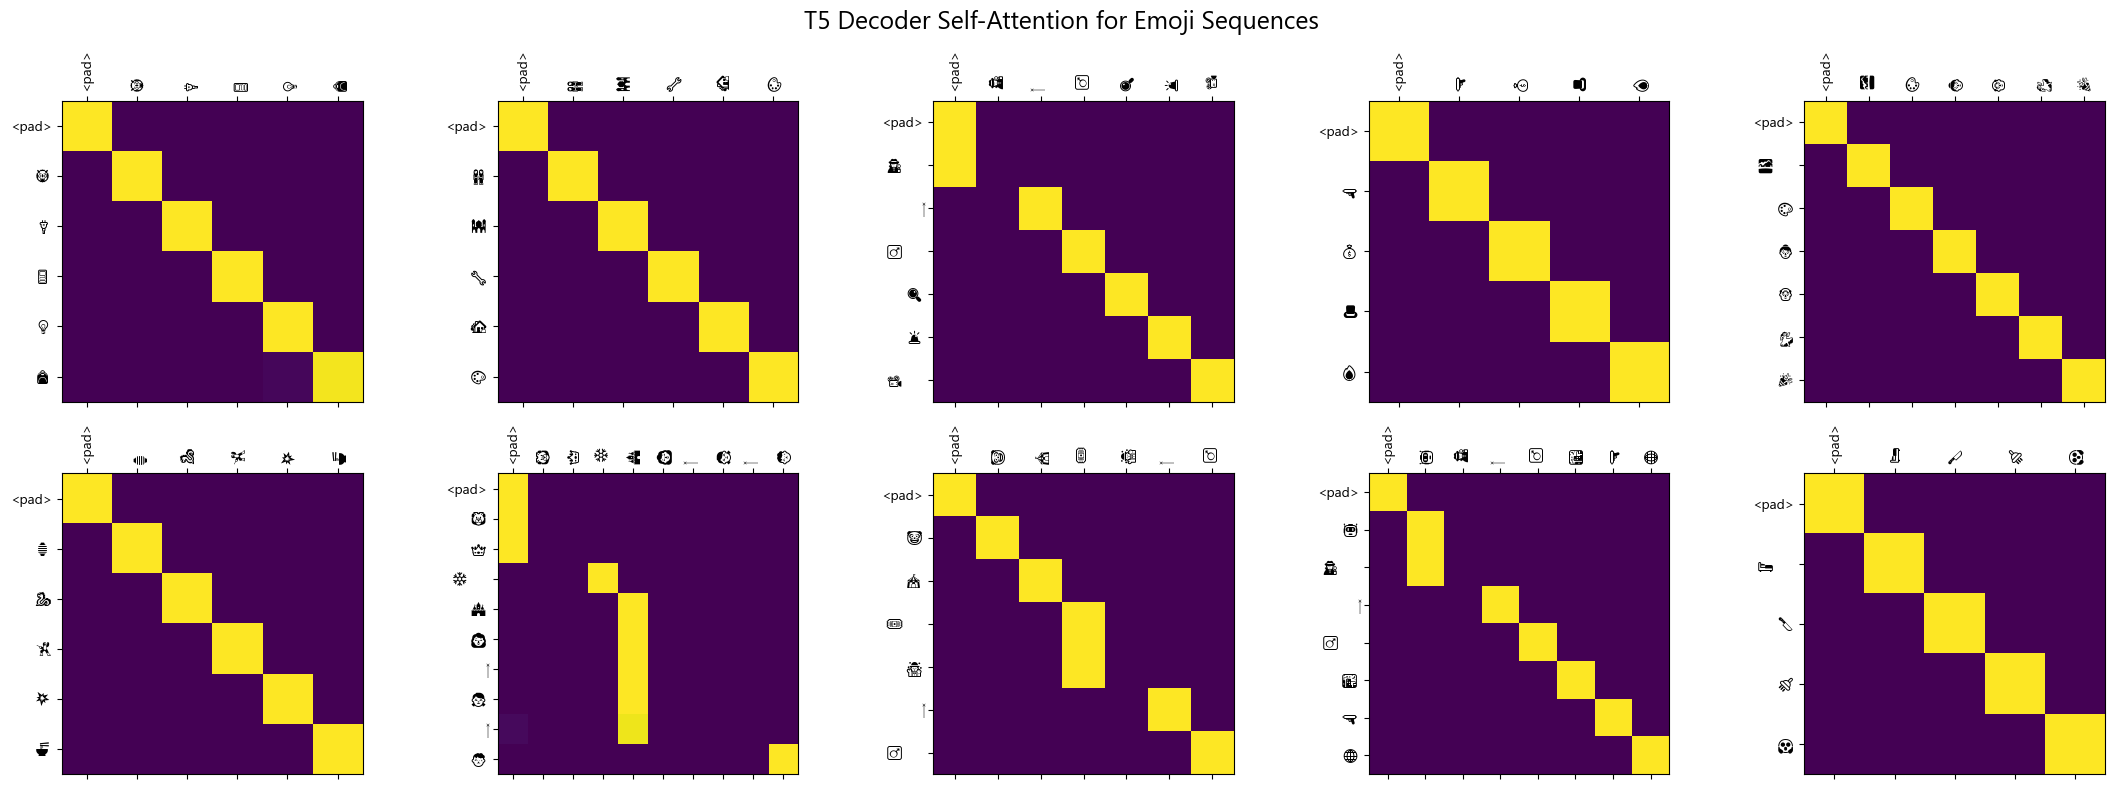

In [87]:
import random
model.eval()
plt.rcParams['font.family'] = "Segoe UI Emoji"

# Emoji detection helper
sample_indices = random.sample(range(len(train_dataset)), 10)
samples = [train_dataset[i] for i in sample_indices]

# Plotting setup
fig, axs = plt.subplots(2, 5, figsize=(22, 8))
axs = axs.flatten()

for i, row in enumerate(samples):
    # Tokenize inputs
    inputs = tokenizer(row['title'], return_tensors="pt")
    targets = tokenizer(text_target=row['emojis'], return_tensors="pt")

    # Prepare decoder inputs (shift right)
    decoder_input_ids = model._shift_right(targets.input_ids)

    decoder_input_ids = decoder_input_ids.to("cuda:0")
    input_ids = inputs.input_ids
    input_ids = input_ids.to("cuda:0")

    # Run model with attentions
    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            decoder_input_ids=decoder_input_ids,
            output_attentions=True,
            return_dict=True,
        )

    # Extract decoder self-attention (layer -1, head 0)
    # Shape: [num_layers, batch, num_heads, tgt_len, tgt_len]
    attn = output.decoder_attentions[-1][0, 0].cpu().numpy()

    # Get tokens for axis labels
    token_ids = decoder_input_ids[0]
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Plot
    ax = axs[i]
    cax = ax.matshow(attn, cmap='viridis')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90)
    ax.set_yticklabels(tokens)
    # ax.set_title(row['emojis'], fontsize=12)

fig.suptitle("T5 Decoder Self-Attention for Emoji Sequences", fontsize=18)
plt.tight_layout()
plt.show()

---

## 🎉 Congratulations!

You have reached the end of the task sheet – excellent work!  

---